# Model Evaluation
This notebook evaluates the trained model on the test set and generates performance metrics.

In [7]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib
import matplotlib.pyplot as plt
%run 01_preprocessing.ipynb
%run 02_model_training.ipynb

## Generate Summary Metric on Test Set

In [8]:
# function to display summary metrics
def summary_metrics(model, X_test_t, y_test_t):
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(dim=1)

    print("Classification Report:")
    print(classification_report(y_test_t, preds))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test_t, preds)
    print(cm)

    # overall accuracy
    accuracy = (preds == y_test_t).float().mean().item()
    print(f"\nOverall Test Accuracy: {accuracy:.4f}")
    print(f"Correct Predictions: {(preds == y_test_t).sum().item()}/{len(y_test_t)}")

Epoch 000 | Train Loss: 1.2204 | Val Loss: 1.0901 | Val Acc: 0.2158
Epoch 005 | Train Loss: 0.8616 | Val Loss: 0.9642 | Val Acc: 0.6005
Epoch 010 | Train Loss: 0.6861 | Val Loss: 0.7857 | Val Acc: 0.7154
Epoch 015 | Train Loss: 0.5784 | Val Loss: 0.6326 | Val Acc: 0.7898
Epoch 020 | Train Loss: 0.5037 | Val Loss: 0.5238 | Val Acc: 0.8298
Epoch 025 | Train Loss: 0.4481 | Val Loss: 0.4495 | Val Acc: 0.8575
Epoch 030 | Train Loss: 0.4066 | Val Loss: 0.3952 | Val Acc: 0.8786
Epoch 035 | Train Loss: 0.3719 | Val Loss: 0.3502 | Val Acc: 0.8956
Epoch 040 | Train Loss: 0.3439 | Val Loss: 0.3129 | Val Acc: 0.9065
Epoch 045 | Train Loss: 0.3197 | Val Loss: 0.2839 | Val Acc: 0.9131
Epoch 050 | Train Loss: 0.2991 | Val Loss: 0.2600 | Val Acc: 0.9190
Epoch 055 | Train Loss: 0.2821 | Val Loss: 0.2399 | Val Acc: 0.9241
Epoch 060 | Train Loss: 0.2657 | Val Loss: 0.2241 | Val Acc: 0.9286
Epoch 065 | Train Loss: 0.2517 | Val Loss: 0.2110 | Val Acc: 0.9322
Epoch 070 | Train Loss: 0.2414 | Val Loss: 0.199

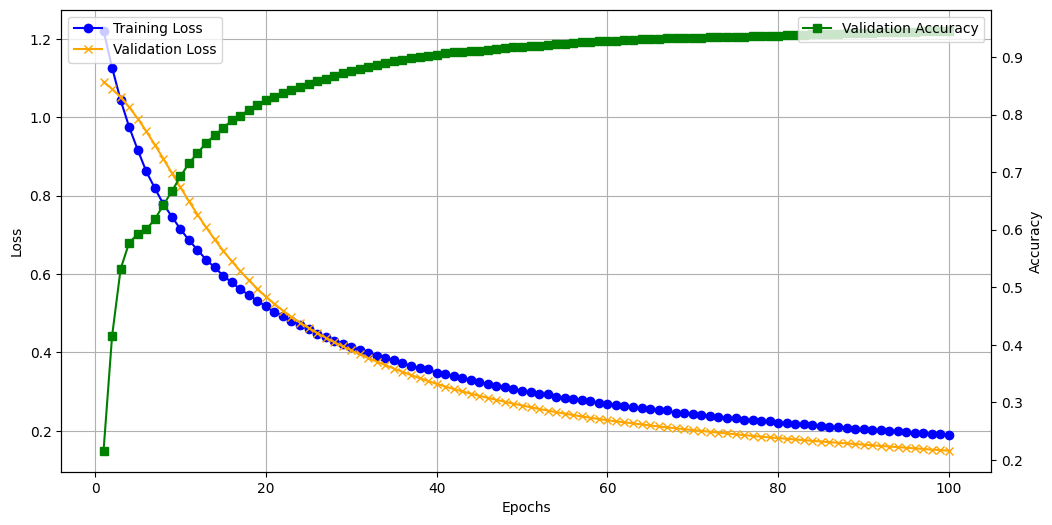

In [ ]:
# main function to run the model training and evaluation
def main(data_src="final_dataset.csv"):
    model, X_test_t, y_test_t, train_losses, val_losses, val_accs = risk_classifier(data_src)
    summary_metrics(model, X_test_t, y_test_t)

    epochs_range = range(1, len(train_losses) + 1)
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(epochs_range, train_losses, label='Training Loss', marker='o', color='blue')
    ax1.plot(epochs_range, val_losses, label='Validation Loss', marker='x', color='orange')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    ax1.legend(loc='best')

    # Plot validation accuracy on a secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(epochs_range, val_accs, label='Validation Accuracy', marker='s', color='green')
    ax2.set_ylabel('Accuracy')
    ax2.legend(loc='upper right')
main()